In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import Image, display

# Thiết lập đường dẫn tương đối từ thư mục notebooks/
BASE = Path("..")
tables = BASE / "outputs" / "tables"
figs = BASE / "outputs" / "figures"

def show_chart(name, caption):
    """Hiển thị biểu đồ từ thư mục figures với chú dẫn"""
    path = figs / name
    if path.exists():
        print(f"--- {caption} ---")
        display(Image(filename=str(path)))
    else:
        print(f"⚠️ Không tìm thấy file biểu đồ: {name}")

# Đọc kết quả từ các file CSV đã lưu
try:
    rules = pd.read_csv(tables / "association_rules.csv")
    forecast = pd.read_csv(tables / "forecast_comparison.csv")
    print("✅ Đã tải dữ liệu kết quả thành công.")
except Exception as e:
    print(f"❌ Lỗi tải dữ liệu: {e}")


✅ Đã tải dữ liệu kết quả thành công.


# Báo cáo Đánh giá Kết quả và Giải pháp (Evaluation Report)

## Mục lục
1. Tổng quan Dự án & Data Dictionary
2. Kiến trúc Giải pháp (Project Architecture)
3. Khai phá Dữ liệu và Tiền xử lý (EDA & Preprocessing)
4. Luật Kết hợp (Association Rules)
5. Gom cụm Đặc trưng Tiêu thụ (Clustering Daily Profiles)
6. Dự báo Chuỗi thời gian (Time Series Forecasting)
7. Phát hiện Bất thường (Anomaly Detection)
8. Đề xuất Giải pháp và Khuyến nghị Thực tế (Actionable Recommendations)

### 1.1 Data Dictionary (Từ điển dữ liệu)
Dựa trên yêu cầu của Topic 10, các trường dữ liệu chính được định nghĩa như sau:

| Tên cột | Ý nghĩa | Đơn vị |
|:---|:---|:---|
| **Global_active_power** | Tổng công suất thực tiêu thụ | Kilowatt (kW) |
| **Global_intensity** | Tổng cường độ dòng điện trung bình | Ampere (A) |
| **Voltage** | Điện áp trung bình | Volt (V) |
| **Sub_metering_1** | Năng lượng tiêu thụ tại Bếp | Watt-hour |
| **Sub_metering_2** | Năng lượng tiêu thụ tại Giặt/Rửa | Watt-hour |
| **Sub_metering_3** | Năng lượng tiêu thụ Điều hòa/Sưởi | Watt-hour |

## 2. Kiến trúc Giải pháp (Project Architecture)
Dự án tuân thủ cấu trúc Pipeline chuyên nghiệp (Tiêu chí H):
- **src/data/**: Module `loader.py` và `cleaner.py` xử lý nội suy dữ liệu khuyết thiếu.
- **src/mining/**: Triển khai các thuật toán `association.py` (Apriori), `clustering.py` (K-Means) và `anomaly.py` (Isolation Forest).
- **src/models/**: Chứa module `forecasting.py` thực hiện ARIMA/Holt-Winters.
- **outputs/**: Lưu trữ toàn bộ Artifacts (PNG, CSV) phục vụ Dashboard và Báo cáo này.

## 3. Khai phá Dữ liệu và Tiền xử lý (EDA & Preprocessing)
**Những phát hiện chính (Insights):**
- Xử lý thành công các giá trị khuyết thiếu bằng phương pháp nội suy trung bình.
- Phát hiện tính chu kỳ theo ngày (daily seasonality) và mùa rõ rệt.

--- Phân phối công suất điện ---


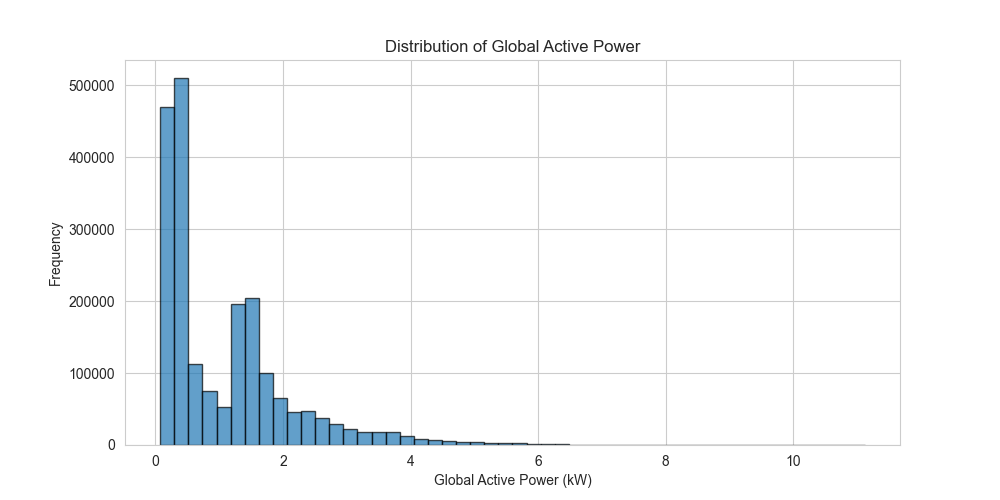

--- Chu kỳ tiêu thụ theo ngày ---


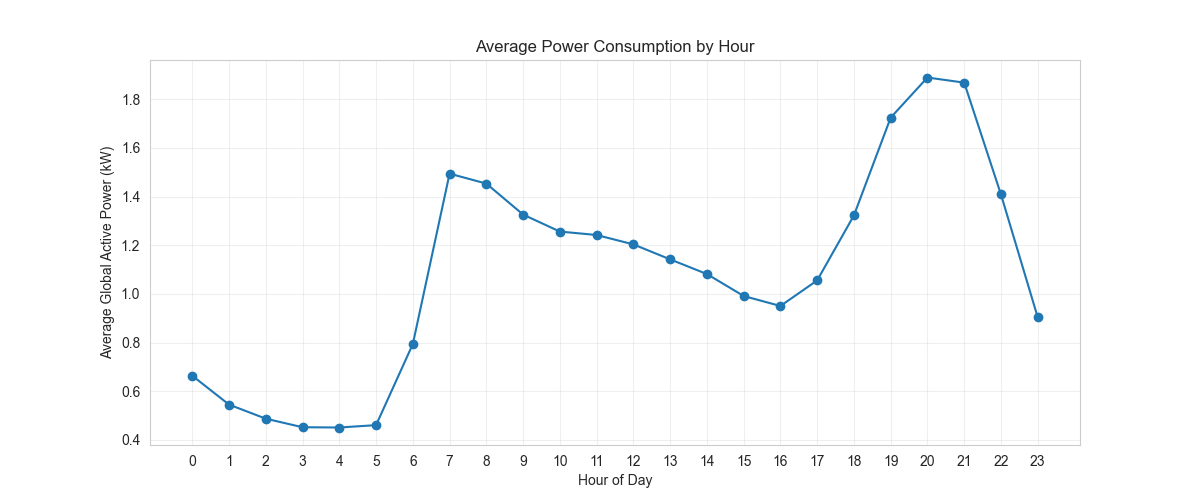

In [14]:
show_chart('power_distribution.png', 'Phân phối công suất điện')
show_chart('daily_pattern.png', 'Chu kỳ tiêu thụ theo ngày')

## 4. Luật Kết hợp (Association Rules)
Sử dụng thuật toán Apriori trên dữ liệu được rời rạc hóa (Low/Medium/High).
**Insights nổi bật:** Có sự liên quan mật thiết giữa Sub_metering_3 (Điều hòa) và Global_active_power ở mức High.

,antecedents,consequents,support,confidence,lift
0,"SubMeter1_Level_High, Power_Level_Medium","Hour_Period_Morning, Day_Type_Weekday, Intensi...",0.0101,0.6392,30.4400
1,"SubMeter1_Level_High, Intensity_Level_Medium","Hour_Period_Morning, Power_Level_Medium, Day_T...",0.0101,0.6392,29.1891
2,"SubMeter1_Level_High, Power_Level_Medium","Hour_Period_Morning, Day_Type_Weekday, Intensi...",0.0102,0.6456,21.5910
3,"SubMeter1_Level_High, Power_Level_Medium, SubM...","Hour_Period_Morning, Day_Type_Weekday, Intensi...",0.0101,0.6433,21.5155
4,"SubMeter1_Level_High, Intensity_Level_Medium, ...","Hour_Period_Morning, Power_Level_Medium, Day_T...",0.0101,0.6474,21.1580


--- Ma trận tương quan giữa các thiết bị ---


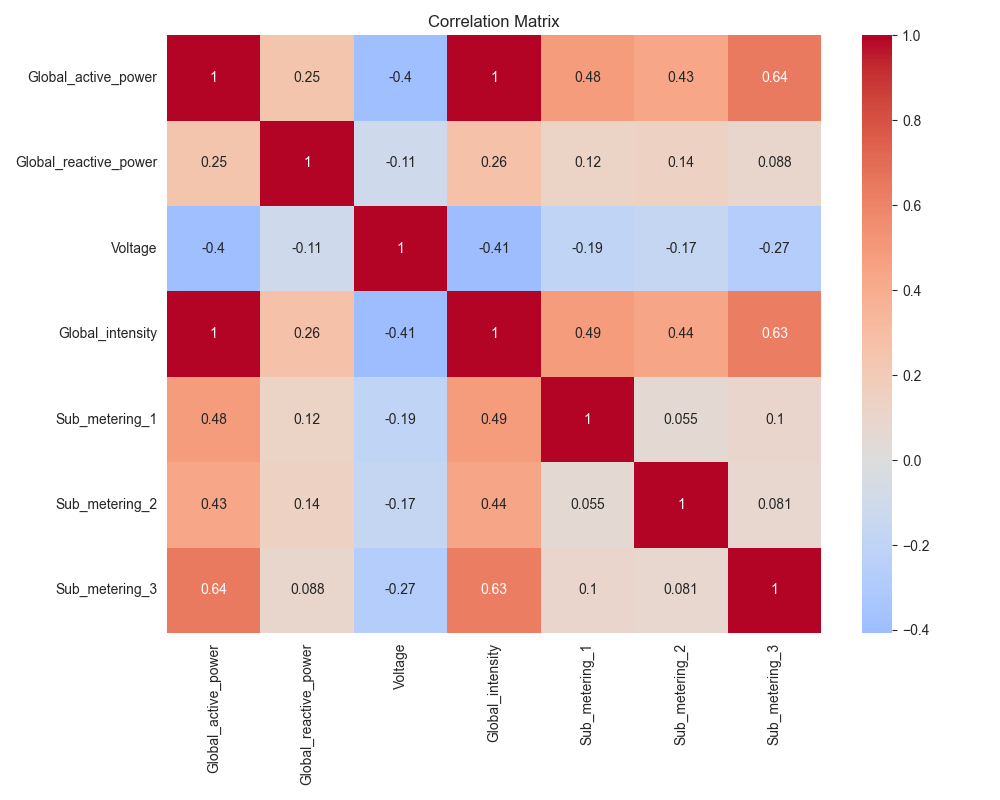

In [15]:
display(rules.head())
show_chart('correlation_heatmap.png', 'Ma trận tương quan giữa các thiết bị')

## 5. Gom cụm (Clustering Daily Profiles)
Thuật toán K-Means phân tách 24 khung giờ thành 3 nhóm hành vi đặc trưng.

--- Đặc trưng 3 cụm hành vi tiêu thụ 24h ---


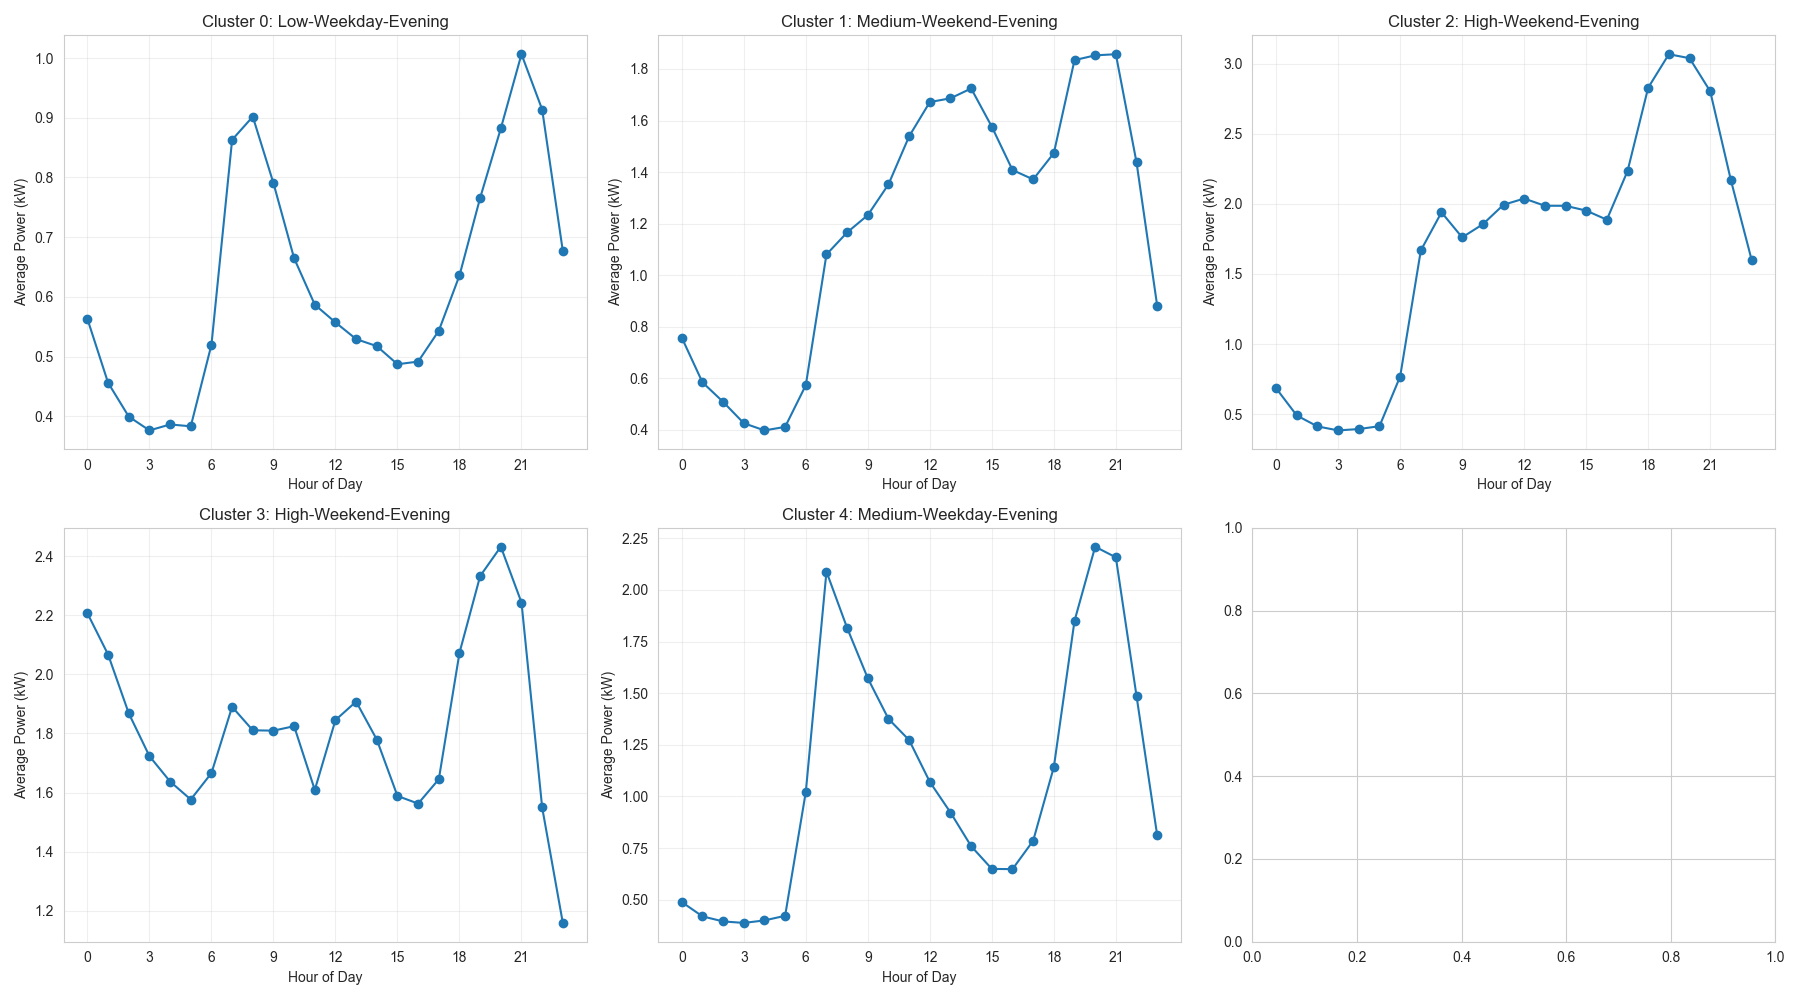

In [16]:
show_chart('cluster_hourly_profiles.png', 'Đặc trưng 3 cụm hành vi tiêu thụ 24h')

## 6. Dự báo Chuỗi thời gian (Time Series Forecasting)
So sánh các mô hình ARIMA, Holt-Winters và Naive.

,Unnamed: 0,MAE,RMSE,MAPE,AIC,BIC
0,Holt-Winters,0.552845,0.788031,48.478574,NaN,NaN
1,Seasonal_Naive,0.676848,0.939164,75.966584,NaN,NaN
2,"ARIMA(1,0,1)",0.681125,0.843073,96.145799,2795.174221,2816.685257
3,Naive,0.879859,1.199709,55.398455,NaN,NaN


--- So sánh các đồ thị dự báo ---


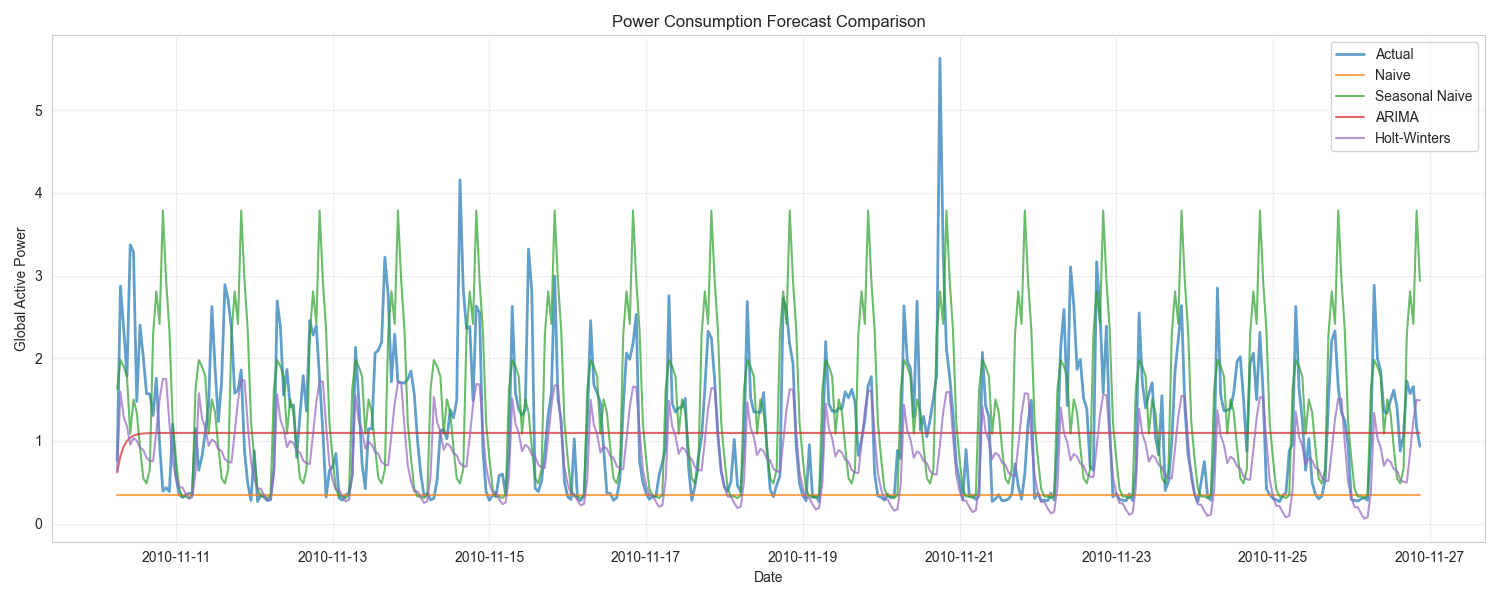

--- Phân tích phần dư Residuals ---


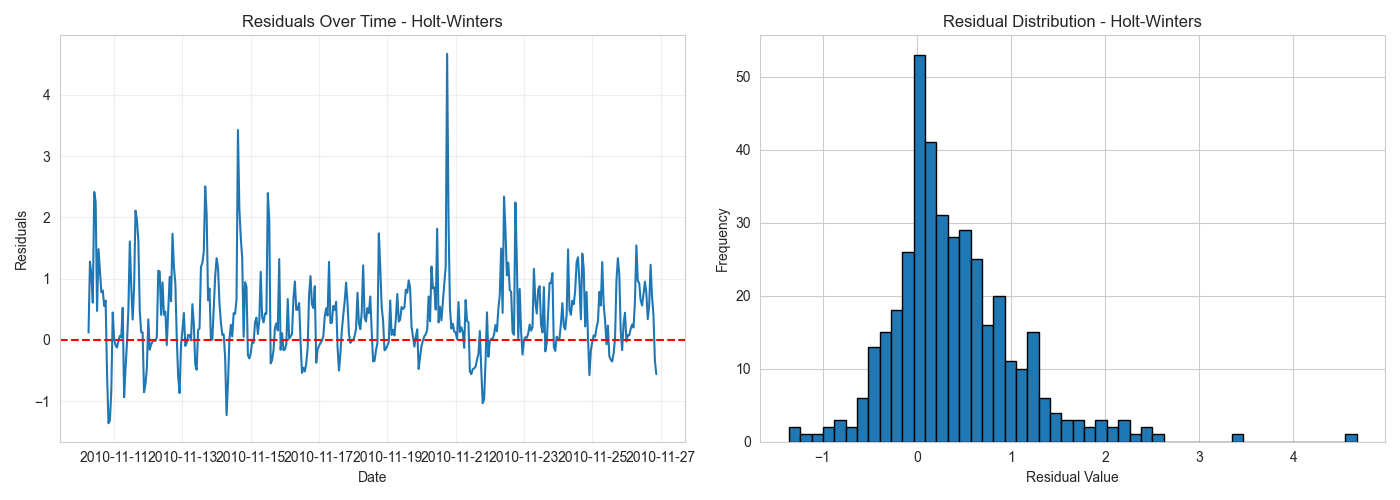

In [17]:
display(forecast)
show_chart('forecast_comparison.png', 'So sánh các đồ thị dự báo')
show_chart('residuals_analysis.png', 'Phân tích phần dư Residuals')

## 7. Phát hiện Bất thường (Anomaly Detection)
Sử dụng **Isolation Forest** để tách biệt các ngày có hành vi tiêu thụ cực đoan.

--- Phát hiện các điểm tiêu thụ bất thường ---


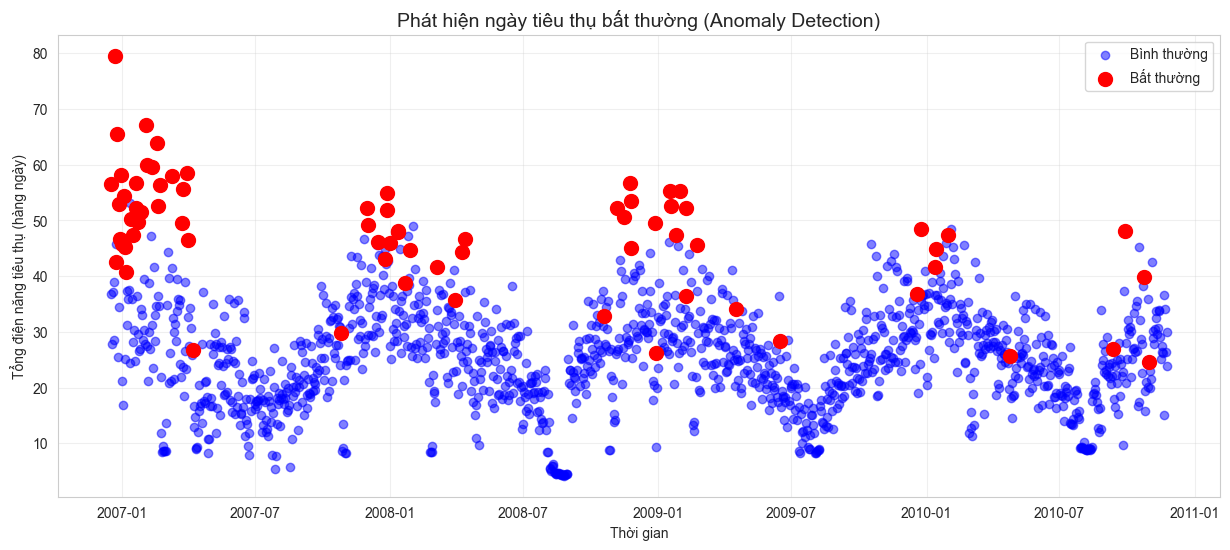

In [18]:
show_chart('anomaly_detection.png', 'Phát hiện các điểm tiêu thụ bất thường')

## 8. Đề xuất Giải pháp và Khuyến nghị Thực tế (Actionable Recommendations)
1. **Tiết kiệm điện gia đình**: Điều phối thiết bị bếp lệch giờ Peak điều hòa.
2. **Cảnh báo rò rỉ**: Dùng Isolation Forest phát hiện sụt áp hoặc rò điện.
3. **Power Grid**: Dự trữ điện dựa trên khung giờ cụm thấp điểm.
4. **Smart Control**: Tự động ngắt thiết bị không cần thiết khi Sub_metering_3 tăng cao.
5. **Cải tiến mô hình**: Tích hợp dữ liệu thời tiết (External features) vào dự báo.